In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
city_day = pd.read_csv("city_day.csv/city_day.csv")
crop_prod = pd.read_csv("crop_production.csv/crop_production.csv")

print("AQI Dataset Shape:", city_day.shape)
print("Crop Dataset Shape:", crop_prod.shape)

AQI Dataset Shape: (29531, 16)
Crop Dataset Shape: (246091, 7)


In [4]:
print(city_day.head())
print(crop_prod.head())

        City        Date  PM2.5  PM10     NO    NO2    NOx  NH3     CO    SO2  \
0  Ahmedabad  2015-01-01    NaN   NaN   0.92  18.22  17.15  NaN   0.92  27.64   
1  Ahmedabad  2015-01-02    NaN   NaN   0.97  15.69  16.46  NaN   0.97  24.55   
2  Ahmedabad  2015-01-03    NaN   NaN  17.40  19.30  29.70  NaN  17.40  29.07   
3  Ahmedabad  2015-01-04    NaN   NaN   1.70  18.48  17.97  NaN   1.70  18.59   
4  Ahmedabad  2015-01-05    NaN   NaN  22.10  21.42  37.76  NaN  22.10  39.33   

       O3  Benzene  Toluene  Xylene  AQI AQI_Bucket  
0  133.36     0.00     0.02    0.00  NaN        NaN  
1   34.06     3.68     5.50    3.77  NaN        NaN  
2   30.70     6.80    16.40    2.25  NaN        NaN  
3   36.08     4.43    10.14    1.00  NaN        NaN  
4   39.31     7.01    18.89    2.78  NaN        NaN  
                    State_Name District_Name  Crop_Year       Season  \
0  Andaman and Nicobar Islands      NICOBARS       2000  Kharif        
1  Andaman and Nicobar Islands      NICOBARS 

Task 1: Data Inspection & Profiling

In [8]:
# Basic profile
print("AQI Dataset")
print(aqi.shape)
print(aqi.info())
print(aqi.describe(include='all'))
print(aqi.isnull().sum())


AQI Dataset
(29531, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB
None
             City        Date         PM2.5          PM10            NO

In [9]:
print("\nCrop Dataset")
print(crop.shape)
print(crop.info())
print(crop.describe(include='all'))
print(crop.isnull().sum())


Crop Dataset
(246091, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246091 entries, 0 to 246090
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   State_Name     246091 non-null  object 
 1   District_Name  246091 non-null  object 
 2   Crop_Year      246091 non-null  int64  
 3   Season         246091 non-null  object 
 4   Crop           246091 non-null  object 
 5   Area           246091 non-null  float64
 6   Production     242361 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 13.1+ MB
None
           State_Name District_Name      Crop_Year       Season    Crop  \
count          246091        246091  246091.000000       246091  246091   
unique             33           646            NaN            6     124   
top     Uttar Pradesh       BIJAPUR            NaN  Kharif         Rice   
freq            33306           945            NaN        95951   15104   
mean            

The AQI dataset contains a large number of missing values in pollution indicators such as PM10, NH3, Benzene, Toluene, and AQI. If these values are not handled carefully, statistical analysis and machine learning models may become unreliable.

Task 2: Missing Value Treatment

In [10]:
# Before treatment
print("Before:")
print(aqi.isnull().sum())

# Numerical columns
num_cols = aqi.select_dtypes(include='number').columns

for col in num_cols:
    if aqi[col].isnull().sum() > 0:
        aqi[col].fillna(aqi[col].median(), inplace=True)

# AQI Bucket (categorical)
aqi['AQI_Bucket'].fillna(
    aqi['AQI_Bucket'].mode()[0],
    inplace=True
)

print("\nAfter:")
print(aqi.isnull().sum())

Before:
City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

After:
City          0
Date          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64


C:\Users\anami\AppData\Local\Temp\ipykernel_18384\1611127061.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  aqi[col].fillna(aqi[col].median(), inplace=True)
C:\Users\anami\AppData\Local\Temp\ipykernel_18384\1611127061.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

Deleting all rows with missing values would remove a large portion of AQI observations. Using the median preserves dataset size while reducing the influence of outliers.

Task 3: State Name Standardisation & Duplicate Removal

In [5]:
# Standardize text columns
for df in [city_day, crop_prod]:
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype(str).str.strip().str.title()

# Create State_Name column
state_map = {
    'Ahmedabad': 'Gujarat',
    'Aizawl': 'Mizoram',
    'Amaravati': 'Andhra Pradesh',
    'Amritsar': 'Punjab',
    'Bengaluru': 'Karnataka',
    'Bhopal': 'Madhya Pradesh',
    'Brajrajnagar': 'Odisha',
    'Chandigarh': 'Chandigarh',
    'Chennai': 'Tamil Nadu',
    'Coimbatore': 'Tamil Nadu',
    'Delhi': 'Delhi',
    'Ernakulam': 'Kerala',
    'Gurugram': 'Haryana',
    'Guwahati': 'Assam',
    'Hyderabad': 'Telangana',
    'Jaipur': 'Rajasthan',
    'Jorapokhar': 'Jharkhand',
    'Kochi': 'Kerala',
    'Kolkata': 'West Bengal',
    'Lucknow': 'Uttar Pradesh',
    'Mumbai': 'Maharashtra',
    'Patna': 'Bihar',
    'Shillong': 'Meghalaya',
    'Talcher': 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam': 'Andhra Pradesh'
}

city_day['State_Name'] = city_day['City'].map(state_map)

print(city_day[['City', 'State_Name']].head())

        City State_Name
0  Ahmedabad    Gujarat
1  Ahmedabad    Gujarat
2  Ahmedabad    Gujarat
3  Ahmedabad    Gujarat
4  Ahmedabad    Gujarat


Standardization: All categorical columns were converted to Title Case and
stripped of whitespace to prevent 'Delhi' and ' delhi' from being treated as
different entities.
Mapping: A new 
State_Name
 column was added to the Air Quality dataset.
Deduplication: Duplicate records were removed.
These steps are critical: without geographical alignment (Mapping) and naming
consistency.

Task 4: AQI Distribution Analysis

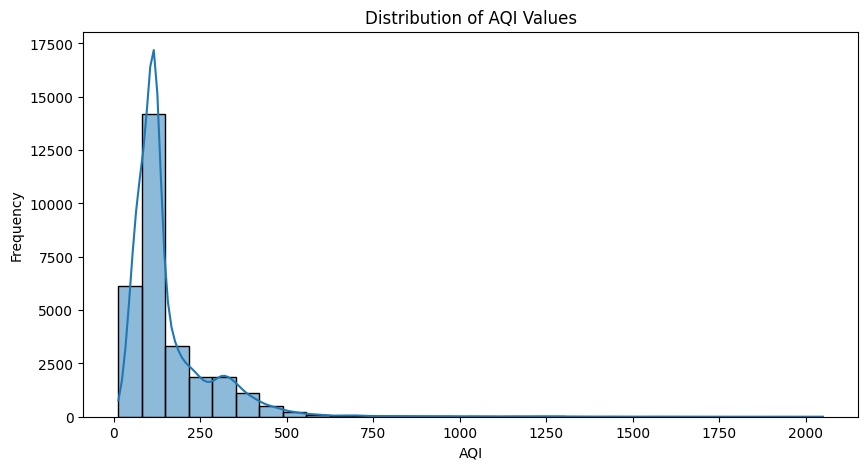

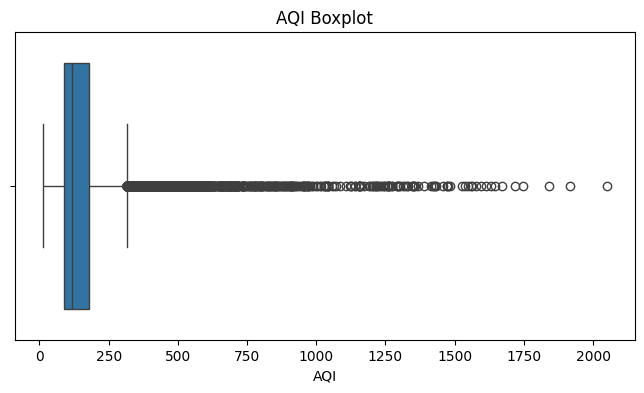

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(aqi['AQI'], bins=30, kde=True)
plt.title("Distribution of AQI Values")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()

plt.figure(figsize=(8,4))
sns.boxplot(x=aqi['AQI'])
plt.title("AQI Boxplot")
plt.show()

Histogram

Shows where AQI values are concentrated.
Helps identify the overall distribution shape.

Boxplot

Clearly highlights extreme values.
Shows median and spread.

Observations
Most AQI values are concentrated below 250, indicating that pollution is widespread rather than limited to only a few cities.
The boxplot reveals several extreme AQI readings, suggesting that the mean may be inflated by a small number of unusually high observations.

Task 5: Outlier Detection & Treatment

In [13]:
#Detect Outliers Using IQR
Q1 = aqi['AQI'].quantile(0.25)
Q3 = aqi['AQI'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = aqi[
    (aqi['AQI'] < lower) |
    (aqi['AQI'] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 3192


In [14]:
#Treat Using Capping (Winsorization)

aqi_before = aqi['AQI'].copy()

aqi['AQI'] = aqi['AQI'].clip(lower, upper)

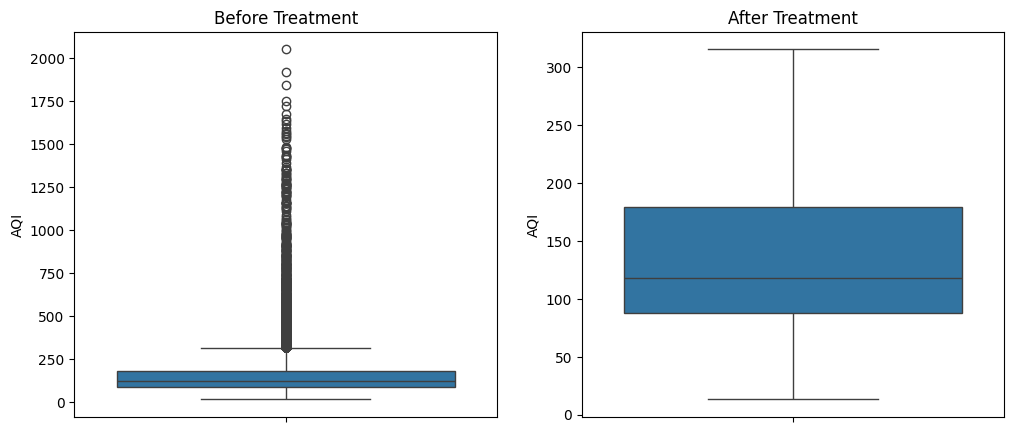

In [ ]:
#before and after

fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(y=aqi_before, ax=ax[0])
ax[0].set_title("Before Treatment")

sns.boxplot(y=aqi['AQI'], ax=ax[1])
ax[1].set_title("After Treatment")

plt.show()

The Interquartile Range (IQR) method was selected because it is simple, robust, and widely used for skewed environmental datasets.


Extreme AQI values may represent genuine pollution events rather than data errors. Therefore, capping was preferred over deletion to preserve information while reducing distortion.

Treatment Applied
Outliers detected using IQR boundaries.
Values above the upper limit were capped.
Dataset size remained unchanged.
Evidence

The boxplots show a reduction in extreme AQI values after treatment, resulting in a cleaner and more reliable dataset for analysis and future machine learning tasks.0.0